In [2]:
import h5py as h5 

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib import colors, ticker

import numpy as np
import pandas as pd
import os, sys
import traceback

from dotenv import load_dotenv

# Load variables from .env
load_dotenv()

import h5flow 
plt.style.use('../utils/dune.mplstyle')
plt.rcParams["font.sans-serif"] = [
    "Helvetica",
    "Helvetica Neue",
    "Nimbus Sans",
    "Liberation Sans",
    "Arial",
    "DejaVu Sans",
]
from sklearn.cluster import DBSCAN 

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

from pathlib import Path

In [3]:
def get_distance(inel_cluster):
    print(inel_cluster['x'])
    print(inel_cluster["x"].iloc[0])
    print(inel_cluster["x"].iloc[1])
    dx = inel_cluster["x"] - inel_cluster["x"]
    dy = inel_cluster["y"] - inel_cluster["y"]
    dz = inel_cluster["z"] - inel_cluster["z"]
    dist = np.sqrt(dx**2 + dy**2 + dz**2)
    return dist

In [4]:
def get_capture_like(df):
    # Remove non-clustered hits
    cluster_energy = [] 
    mean_position = []
    inel_cluster_energy = [] 
    df_filtered = df[df["cluster_label"]!=-1]
    unique_clusters = np.unique(df_filtered["id"])
    for icluster in unique_clusters:
        this_cluster = df_filtered[df_filtered['id']==icluster]
        if((len(this_cluster)>=5)):
            x_mean = np.mean(this_cluster['x'])
            y_mean = np.mean(this_cluster['y'])
            z_mean = np.mean(this_cluster['z'])
            mean_position.append([x_mean,y_mean,z_mean])
            cluster_energy.append(np.sum(this_cluster['E']))

        if((len(this_cluster)<=2)):
            inel_cluster_energy.append(np.sum(this_cluster['E']))
    
    return cluster_energy, np.array(mean_position), inel_cluster_energy
    

In [5]:
def charge_to_energy_mev(charge_ke):
    return (np.asarray(charge_ke, dtype=np.float64) * 1e3 * 23.6) / 0.58 / 1e6

In [6]:
# Measured live time for each input HDF5 file, in minutes.
# The CSV filenames contain the same packet basename, so they can be matched exactly.
_EXPOSURE_TABLE = """
packet-0060072-2025_11_02_11_35_36_CST.FLOW.HDF5 15.010
packet-0060072-2025_11_02_11_50_38_CST.FLOW.HDF5 15.012
packet-0060072-2025_11_02_12_05_39_CST.FLOW.HDF5 15.011
packet-0060072-2025_11_02_12_20_40_CST.FLOW.HDF5 15.014
packet-0060072-2025_11_02_12_35_41_CST.FLOW.HDF5 15.015
packet-0060072-2025_11_02_12_50_42_CST.FLOW.HDF5 15.015
packet-0060072-2025_11_02_13_05_43_CST.FLOW.HDF5 15.014
packet-0060072-2025_11_02_13_20_44_CST.FLOW.HDF5 15.011
packet-0060072-2025_11_02_13_35_45_CST.FLOW.HDF5 15.009
packet-0060072-2025_11_02_13_50_46_CST.FLOW.HDF5 14.997
packet-0060072-2025_11_02_14_05_47_CST.FLOW.HDF5 15.009
packet-0060072-2025_11_02_14_20_49_CST.FLOW.HDF5 14.996
packet-0060072-2025_11_02_14_50_51_CST.FLOW.HDF5 15.006
packet-0060072-2025_11_02_15_05_52_CST.FLOW.HDF5 14.998
packet-0060072-2025_11_02_15_20_53_CST.FLOW.HDF5 15.006
packet-0060072-2025_11_02_15_35_54_CST.FLOW.HDF5 10.707
packet-0060073-2025_11_02_17_44_43_CST.FLOW.HDF5 15.011
packet-0060073-2025_11_02_17_59_45_CST.FLOW.HDF5 15.009
packet-0060073-2025_11_02_18_14_46_CST.FLOW.HDF5 15.014
packet-0060073-2025_11_02_18_29_47_CST.FLOW.HDF5 15.014
packet-0060073-2025_11_02_18_44_48_CST.FLOW.HDF5 15.014
packet-0060073-2025_11_02_18_59_49_CST.FLOW.HDF5 15.012
packet-0060073-2025_11_02_19_14_50_CST.FLOW.HDF5 15.011
packet-0060073-2025_11_02_19_29_51_CST.FLOW.HDF5 15.013
packet-0060073-2025_11_02_19_44_52_CST.FLOW.HDF5 14.999
packet-0060073-2025_11_02_19_59_54_CST.FLOW.HDF5 14.998
packet-0060073-2025_11_02_20_14_55_CST.FLOW.HDF5 14.998
packet-0060073-2025_11_02_20_29_56_CST.FLOW.HDF5 15.006
packet-0060073-2025_11_02_20_44_57_CST.FLOW.HDF5 15.008
packet-0060073-2025_11_02_20_59_58_CST.FLOW.HDF5 15.006
packet-0060073-2025_11_02_21_14_59_CST.FLOW.HDF5 15.008
packet-0060073-2025_11_02_21_30_00_CST.FLOW.HDF5 15.010
packet-0060073-2025_11_02_21_45_01_CST.FLOW.HDF5 15.009
packet-0060073-2025_11_02_22_00_02_CST.FLOW.HDF5 15.012
packet-0060073-2025_11_02_22_15_03_CST.FLOW.HDF5 15.013
packet-0060073-2025_11_02_22_30_04_CST.FLOW.HDF5 15.015
packet-0060073-2025_11_02_22_45_05_CST.FLOW.HDF5 15.015
packet-0060073-2025_11_02_23_00_06_CST.FLOW.HDF5 15.013
packet-0060073-2025_11_02_23_30_09_CST.FLOW.HDF5 5.480
packet-0060074-2025_11_02_23_48_54_CST.FLOW.HDF5 14.999
packet-0060074-2025_11_03_00_03_56_CST.FLOW.HDF5 14.999
packet-0060074-2025_11_03_00_18_57_CST.FLOW.HDF5 15.006
packet-0060074-2025_11_03_00_33_58_CST.FLOW.HDF5 15.008
packet-0060074-2025_11_03_00_48_59_CST.FLOW.HDF5 15.007
packet-0060074-2025_11_03_01_04_00_CST.FLOW.HDF5 15.010
packet-0060074-2025_11_03_01_19_01_CST.FLOW.HDF5 15.012
packet-0060074-2025_11_03_01_34_02_CST.FLOW.HDF5 15.013
packet-0060074-2025_11_03_01_49_03_CST.FLOW.HDF5 15.015
packet-0060074-2025_11_03_02_04_04_CST.FLOW.HDF5 15.014
packet-0060074-2025_11_03_02_19_05_CST.FLOW.HDF5 15.013
packet-0060074-2025_11_03_02_34_06_CST.FLOW.HDF5 15.012
packet-0060074-2025_11_03_02_49_08_CST.FLOW.HDF5 14.999
packet-0060074-2025_11_03_03_04_09_CST.FLOW.HDF5 15.005
packet-0060074-2025_11_03_03_19_10_CST.FLOW.HDF5 15.006
packet-0060074-2025_11_03_03_34_11_CST.FLOW.HDF5 15.007
packet-0060074-2025_11_03_03_49_12_CST.FLOW.HDF5 15.008
packet-0060074-2025_11_03_04_04_13_CST.FLOW.HDF5 15.009
packet-0060074-2025_11_03_04_19_14_CST.FLOW.HDF5 15.006
packet-0060074-2025_11_03_04_34_15_CST.FLOW.HDF5 15.010
packet-0060074-2025_11_03_04_49_16_CST.FLOW.HDF5 15.013
packet-0060074-2025_11_03_05_04_17_CST.FLOW.HDF5 15.013
packet-0060074-2025_11_03_05_19_18_CST.FLOW.HDF5 15.014
packet-0060074-2025_11_03_05_34_19_CST.FLOW.HDF5 15.015
packet-0060074-2025_11_03_05_49_20_CST.FLOW.HDF5 15.014
packet-0060074-2025_11_03_06_04_21_CST.FLOW.HDF5 15.012
packet-0060074-2025_11_03_06_19_22_CST.FLOW.HDF5 15.011
packet-0060074-2025_11_03_06_34_24_CST.FLOW.HDF5 15.004
packet-0060074-2025_11_03_06_49_25_CST.FLOW.HDF5 15.006
packet-0060074-2025_11_03_07_04_26_CST.FLOW.HDF5 15.015
packet-0060074-2025_11_03_07_19_27_CST.FLOW.HDF5 15.005
packet-0060074-2025_11_03_07_34_28_CST.FLOW.HDF5 15.007
packet-0060074-2025_11_03_07_49_29_CST.FLOW.HDF5 15.007
packet-0060074-2025_11_03_08_19_31_CST.FLOW.HDF5 15.010
packet-0060074-2025_11_03_08_34_32_CST.FLOW.HDF5 5.563
packet-0060080-2025_11_04_09_46_37_CST.FLOW.HDF5 15.005
packet-0060080-2025_11_04_10_01_39_CST.FLOW.HDF5 1.700
packet-0060081-2025_11_04_10_09_03_CST.FLOW.HDF5 14.996
packet-0060081-2025_11_04_10_24_06_CST.FLOW.HDF5 14.997
packet-0060081-2025_11_04_10_39_07_CST.FLOW.HDF5 15.004
packet-0060081-2025_11_04_10_54_08_CST.FLOW.HDF5 15.005
packet-0060081-2025_11_04_11_09_09_CST.FLOW.HDF5 15.007
packet-0060081-2025_11_04_11_24_10_CST.FLOW.HDF5 15.005
packet-0060081-2025_11_04_11_39_11_CST.FLOW.HDF5 15.008
packet-0060081-2025_11_04_11_54_12_CST.FLOW.HDF5 15.009
packet-0060081-2025_11_04_12_09_13_CST.FLOW.HDF5 15.012
packet-0060081-2025_11_04_12_24_14_CST.FLOW.HDF5 15.013
packet-0060081-2025_11_04_12_39_15_CST.FLOW.HDF5 15.014
packet-0060081-2025_11_04_12_54_16_CST.FLOW.HDF5 15.000
packet-0060081-2025_11_04_13_09_17_CST.FLOW.HDF5 14.998
packet-0060081-2025_11_04_13_24_19_CST.FLOW.HDF5 14.995
packet-0060081-2025_11_04_13_39_20_CST.FLOW.HDF5 14.999
packet-0060081-2025_11_04_13_54_21_CST.FLOW.HDF5 15.004
packet-0060081-2025_11_04_14_09_22_CST.FLOW.HDF5 7.699
"""

EXPOSURE_MINUTES = {
    filename: float(minutes)
    for filename, minutes in (
        line.split() for line in _EXPOSURE_TABLE.splitlines() if line.strip()
    )
}

def hdf5_exposure_key(csv_path):
    csv_name = Path(csv_path).name
    packet_name = csv_name[csv_name.index("packet-"):]
    if not packet_name.endswith(".csv"):
        raise ValueError(f"Expected a .csv filename, got {csv_name}")
    return packet_name[:-4] + ".HDF5"

def exposure_minutes_for(csv_paths):
    keys = [hdf5_exposure_key(path) for path in csv_paths]
    missing = [key for key in keys if key not in EXPOSURE_MINUTES]
    if missing:
        raise KeyError(f"Missing exposure for {len(missing)} file(s): {missing}")
    return np.asarray([EXPOSURE_MINUTES[key] for key in keys])

In [7]:
def process_one_file(input_csv):
    df = pd.read_csv(input_csv,usecols=['light_id','file_id',
                                        'cluster_label','Q',
                                        'E','x','y','z'])
    n_events = df[["light_id", "file_id"]].drop_duplicates().shape[0] 
    cluster_summary = (
    df[df["cluster_label"] != -1]
    .groupby(["file_id", "light_id", "cluster_label"],sort=False)
    .agg(
        n_hits=("E", "size"),
        total_energy=("E", "sum"),
        cluster_charge=("Q","sum"),
        mean_x=("x", "mean"),
        mean_y=("y", "mean"),
        mean_z=("z", "mean"),
    )
    .reset_index()  # parentheses matter
    )

    cluster_summary["total_E_ee"] = charge_to_energy_mev(
        cluster_summary["cluster_charge"]
    )

    print(f"{Path(input_csv).name}: {n_events} events")
    cluster_summary["source_file"] = Path(input_csv).name
    return cluster_summary

In [8]:
input_MC_source ="/pscratch/sd/l/lmlepin/AmBe_MC_top_mod2_PROD_03-21/AmBe_MC_top_mod2_PROD_03-21.csv"
cluster_summary_MC = process_one_file(input_MC_source)
print(cluster_summary_MC.head())

AmBe_MC_top_mod2_PROD_03-21.csv: 18492 events
   file_id  light_id  cluster_label  n_hits  total_energy  cluster_charge  \
0      0.0       0.0            0.0       1      0.631525       18.764300   
1      0.0       1.0            0.0       3      1.525004       45.311965   
2      0.0       2.0            0.0       1      0.875272       26.006677   
3      0.0       2.0            1.0       1      0.285033        8.469104   
4      0.0       3.0            0.0       8      3.538747      105.145704   

      mean_x     mean_y     mean_z  total_E_ee  \
0  25.915130 -17.070900  64.316299    0.763513   
1 -54.425893  -7.306863  61.628189    1.843728   
2  44.197954  -0.221700 -37.268902    1.058203   
3  28.629099   8.646300  -7.117700    0.344605   
4  22.169454  21.006075  42.977675    4.278342   

                       source_file  
0  AmBe_MC_top_mod2_PROD_03-21.csv  
1  AmBe_MC_top_mod2_PROD_03-21.csv  
2  AmBe_MC_top_mod2_PROD_03-21.csv  
3  AmBe_MC_top_mod2_PROD_03-21.csv  
4  Am

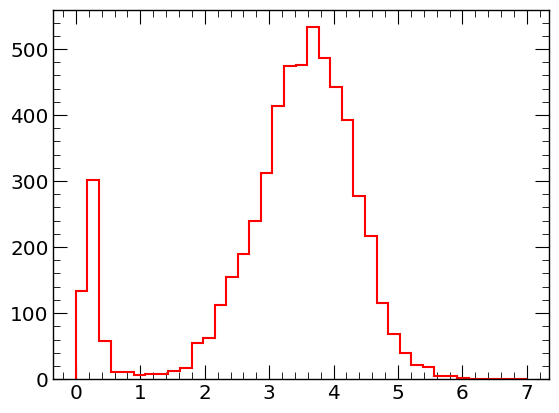

In [9]:
max_hits = 5
cluster_summary_MC_cut = cluster_summary_MC.loc[cluster_summary_MC["n_hits"] >= max_hits]
plt.hist(cluster_summary_MC_cut['total_E_ee'],bins=np.linspace(0,7,40),histtype='step',color='red')
plt.show()


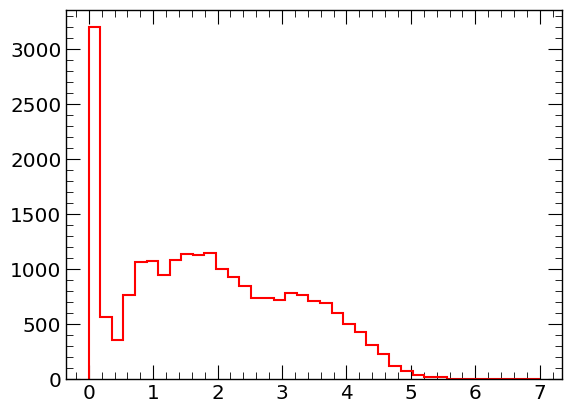

In [10]:
max_hits = 2
cluster_summary_MC_cut = cluster_summary_MC.loc[cluster_summary_MC["n_hits"] >= max_hits]
plt.hist(cluster_summary_MC_cut['total_E_ee'],bins=np.linspace(0,7,40),histtype='step',color='red')
plt.show()

In [11]:
# One file test

input_csv_no_source = "/pscratch/sd/l/lmlepin/my_test/run2_ambe_threshold_trigger_packet-0060081-2025_11_04_11_09_09_CST.FLOW.csv"
summary = process_one_file(input_csv_no_source)
print(summary.head())


run2_ambe_threshold_trigger_packet-0060081-2025_11_04_11_09_09_CST.FLOW.csv: 15346 events
   file_id  light_id  cluster_label  n_hits  total_energy  cluster_charge  \
0      6.0       0.0            0.0       1      0.629294       17.699964   
1      6.0       0.0            1.0       1      0.631122       17.589716   
2      6.0       0.0            2.0       1      0.284467        8.391110   
3      6.0       1.0            0.0       6      2.414228       68.467065   
4      6.0       1.0            1.0       1      0.196525        5.729072   

     mean_x     mean_y     mean_z  total_E_ee  \
0 -53.94227  38.354099  -4.457300    0.720205   
1 -52.29595  47.665501  -4.013900    0.715719   
2  -4.49370  56.838337  27.098412    0.341431   
3  55.49361  60.228500  63.281700    2.785901   
4  -6.61492  39.240898 -42.589699    0.233114   

                                         source_file  
0  run2_ambe_threshold_trigger_packet-0060081-202...  
1  run2_ambe_threshold_trigger_packet-0060

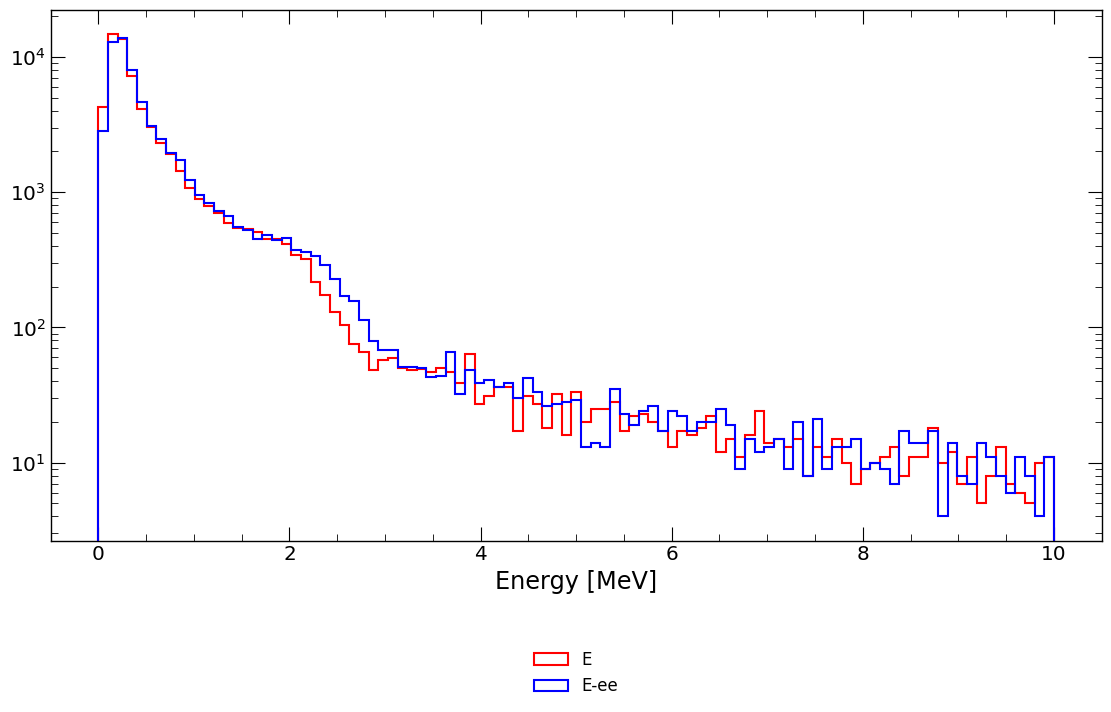

In [12]:
plt.figure(figsize=(11, 7), layout="constrained")
plt.hist(summary['total_energy'],bins=np.linspace(0,10,100),histtype='step',color='red',label='E')
plt.hist(summary['total_E_ee'],bins=np.linspace(0,10,100),histtype='step',color='blue',label='E-ee')
plt.yscale('log')
plt.xlabel('Energy [MeV]')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.show()

In [13]:
# Load source-in data 

input_directory = Path("/pscratch/sd/l/lmlepin/my_test")
pattern = "run2_ambe_threshold_trigger_packet-*_CST.FLOW.csv"
source_files = sorted(input_directory.glob(pattern))

if not source_files:
    raise ValueError("No source-in files matched the input pattern")

source_file_exposures_min = exposure_minutes_for(source_files)
source_exposure_min = source_file_exposures_min.sum()
print(f"Found {len(source_files)} source-in files ({source_exposure_min:.3f} minutes)")

summaries = []
for path in source_files:
    summaries.append(process_one_file(path))


cluster_summary = pd.concat(summaries,ignore_index=True)
del summaries 

Found 19 source-in files (264.470 minutes)
run2_ambe_threshold_trigger_packet-0060080-2025_11_04_09_46_37_CST.FLOW.csv: 15218 events
run2_ambe_threshold_trigger_packet-0060080-2025_11_04_10_01_39_CST.FLOW.csv: 1659 events
run2_ambe_threshold_trigger_packet-0060081-2025_11_04_10_09_03_CST.FLOW.csv: 15131 events
run2_ambe_threshold_trigger_packet-0060081-2025_11_04_10_24_06_CST.FLOW.csv: 15206 events
run2_ambe_threshold_trigger_packet-0060081-2025_11_04_10_39_07_CST.FLOW.csv: 15262 events
run2_ambe_threshold_trigger_packet-0060081-2025_11_04_10_54_08_CST.FLOW.csv: 15316 events
run2_ambe_threshold_trigger_packet-0060081-2025_11_04_11_09_09_CST.FLOW.csv: 15346 events
run2_ambe_threshold_trigger_packet-0060081-2025_11_04_11_24_10_CST.FLOW.csv: 15069 events
run2_ambe_threshold_trigger_packet-0060081-2025_11_04_11_39_11_CST.FLOW.csv: 15034 events
run2_ambe_threshold_trigger_packet-0060081-2025_11_04_11_54_12_CST.FLOW.csv: 15230 events
run2_ambe_threshold_trigger_packet-0060081-2025_11_04_12_0

In [14]:
input_directory = Path("/pscratch/sd/l/lmlepin/clusters_run2_cosmics_1102/")
pattern = "run2_cosmics_1102_threshold_trigger_packet-*_CST.FLOW.csv"
background_files = sorted(input_directory.glob(pattern))

if not background_files:
    raise ValueError("No background files matched the input pattern")

background_file_exposures_min = exposure_minutes_for(background_files)
background_exposure_min = background_file_exposures_min.sum()
print(f"Found {len(background_files)} background files ({background_exposure_min:.3f} minutes)")

summaries = []
for path in background_files:
    summaries.append(process_one_file(path))


cluster_summary_bkg = pd.concat(summaries,ignore_index=True)
del summaries 

Found 74 background files (1087.385 minutes)
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_11_35_36_CST.FLOW.csv: 15205 events
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_11_50_38_CST.FLOW.csv: 14947 events
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_12_05_39_CST.FLOW.csv: 14992 events
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_12_20_40_CST.FLOW.csv: 15076 events
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_12_35_41_CST.FLOW.csv: 14971 events
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_12_50_42_CST.FLOW.csv: 15135 events
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_13_05_43_CST.FLOW.csv: 15089 events
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_13_20_44_CST.FLOW.csv: 15125 events
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_13_35_45_CST.FLOW.csv: 15020 events
run2_cosmics_1102_threshold_trigger_packet-0060072-2025_11_02_13_50_46_CS

In [15]:
#hits cut 
min_hits = 5
cluster_summary_cut = cluster_summary.loc[cluster_summary["n_hits"] >= min_hits]
cluster_summary_bkg_cut = cluster_summary_bkg.loc[cluster_summary_bkg["n_hits"] >= min_hits]
cluster_summary_MC_cut = cluster_summary_MC.loc[cluster_summary_MC["n_hits"] >= min_hits]


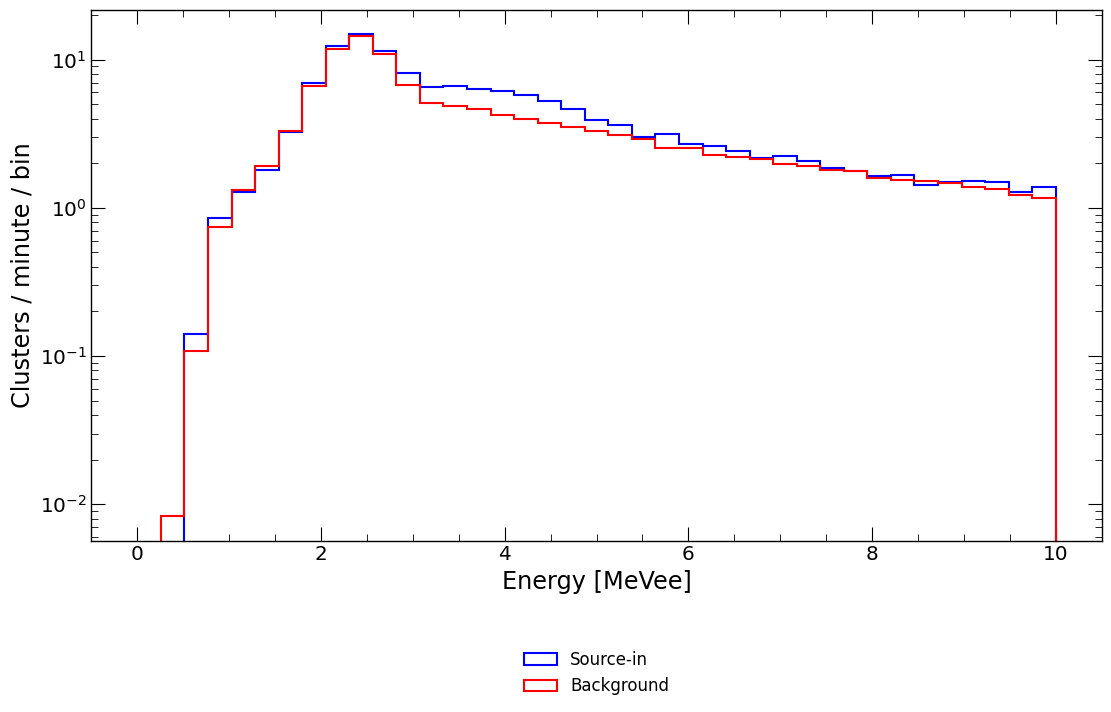

In [16]:
plt.figure(figsize=(11, 7), layout="constrained")
energy_bins = np.linspace(0, 10, 40)
plt.hist(
    cluster_summary_cut["total_E_ee"], bins=energy_bins, histtype="step", color="blue",
    weights=np.full(len(cluster_summary_cut), 1.0 / source_exposure_min), label="Source-in",
)
plt.hist(
    cluster_summary_bkg_cut["total_E_ee"], bins=energy_bins, histtype="step", color="red",
    weights=np.full(len(cluster_summary_bkg_cut), 1.0 / background_exposure_min), label="Background",
)
plt.yscale('log')
plt.xlabel('Energy [MeVee]')
plt.ylabel('Clusters / minute / bin')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.show()

### Background-subtracted data and MC

Each live-time-normalized comparison is followed by a subtraction-only figure with the
same data rates, propagated uncertainties, and peak lines. Legends sit below the axes.

MC uses the same hit cut, energy conversion, and energy bins as data in each comparison.
The rate overlays use `mc_rate_scale = 1 / source_exposure_min` by default: this assigns
the MC sample the source-in live time **only as a nominal plotting scale**, not a calibrated
MC prediction. Adjust this factor below if a better normalization becomes available.

The separate shape figures normalize each histogram to unit signed area over the common
0–7 MeVee range, independently of `mc_rate_scale`. Negative background-subtracted bins
are retained. Error bars propagate independent Poisson counting uncertainties, including
the uncertainty of the normalization sum (first-order propagation). Normalization also
correlates bins; the bars show marginal uncertainties only. Shape comparisons are skipped
with a message if either histogram has a nonpositive or nonfinite total.


In [17]:
# Nominal MC rate per simulated cluster; replace with a calibrated scale if known.
mc_rate_scale = 1.0 / source_exposure_min


def normalized_density(values, uncertainties, bins):
    """Unit signed area, with normalization uncertainty propagated per bin."""
    total = np.sum(values)
    if not np.isfinite(total) or total <= 0:
        raise ValueError("Unit-area normalization requires a positive finite total")
    fractions = values / total
    variances = np.square(uncertainties)
    # Cov(values_i, total) = variance_i for independent input bins.
    fraction_variances = (
        (1.0 - fractions)**2 * variances
        + fractions**2 * np.maximum(variances.sum() - variances, 0.0)
    ) / total**2
    widths = np.diff(bins)
    return fractions / widths, np.sqrt(fraction_variances) / widths


def plot_data_mc_comparison(
    subtracted_rate, subtracted_uncertainty, mc_counts, bins,
    selection_label, peaks=(), normalize=False, show_mc=True,
):
    """Plot background-subtracted data, optionally overlaying MC with common bins and cuts."""
    mc_uncertainty = np.sqrt(mc_counts)
    if normalize:
        totals = (np.sum(subtracted_rate), np.sum(mc_counts))
        if any(not np.isfinite(total) or total <= 0 for total in totals):
            print(f"Skipping shape comparison ({selection_label}): "
                  f"positive finite totals required; data={totals[0]}, MC={totals[1]}")
            return
        data_values, data_errors = normalized_density(
            subtracted_rate, subtracted_uncertainty, bins,
        )
        mc_values, mc_errors = normalized_density(mc_counts, mc_uncertainty, bins)
        mc_label = "MC (unit area)"
    else:
        data_values, data_errors = subtracted_rate, subtracted_uncertainty
        mc_values = mc_counts * mc_rate_scale
        mc_errors = mc_uncertainty * abs(mc_rate_scale)
        mc_label = "MC (nominal scale)"

    centers = 0.5 * (bins[:-1] + bins[1:])
    fig, ax = plt.subplots(figsize=(11, 7), layout="constrained")
    spectra = [(data_values, data_errors, "blue", "Source-in − background")]
    if show_mc:
        spectra.append((mc_values, mc_errors, "darkorange", mc_label))
    for values, errors, color, label in spectra:
        ax.stairs(values, bins, color=color, label=label)
        ax.errorbar(centers, values, yerr=errors, fmt="none",
                    ecolor=color, alpha=0.5, capsize=2)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    for energy, label in peaks:
        ax.axvline(energy, linestyle="--", color="red", label=label)
    ax.set_xlim(bins[0], bins[-1])
    ax.set_xlabel("Energy [MeVee]")
    ax.set_ylabel("Normalized density [MeVee⁻¹]" if normalize
                  else "Clusters / minute / bin", fontsize=15)
    title = "Unit-area shape comparison" if normalize else "Live-time-normalized background subtraction"
    ax.set_title(f"{title} ({selection_label})")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18))
    plt.show()
    return fig, ax


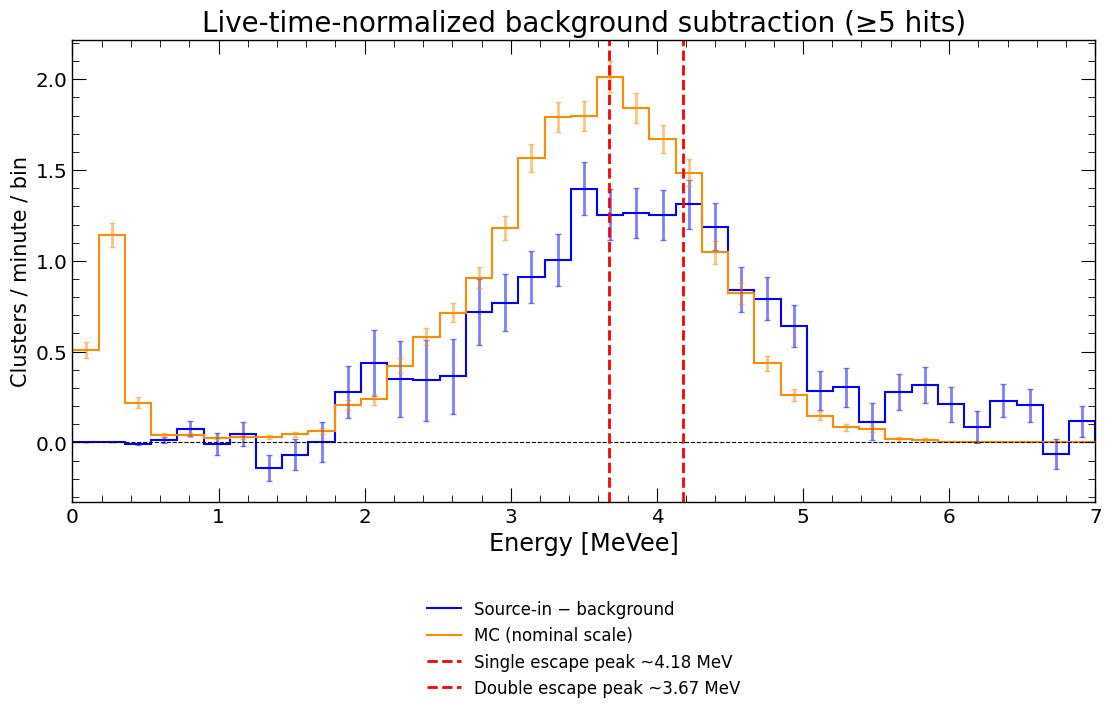

In [18]:
# Subtract exposure-normalized rates using common energy bins for data and MC.
energy_bins = np.linspace(0, 7., 40)
source_counts, _ = np.histogram(cluster_summary_cut["total_E_ee"], bins=energy_bins)
background_counts, _ = np.histogram(cluster_summary_bkg_cut["total_E_ee"], bins=energy_bins)
mc_counts, _ = np.histogram(cluster_summary_MC_cut["total_E_ee"], bins=energy_bins)

source_rate = source_counts / source_exposure_min
background_rate = background_counts / background_exposure_min
subtracted_rate = source_rate - background_rate

# Independent Poisson counting uncertainty, propagated after exposure normalization.
subtracted_rate_uncertainty = np.sqrt(
    source_counts / source_exposure_min**2
    + background_counts / background_exposure_min**2
)
selection_label = f"≥{min_hits} hits"
peaks = [(4.18, "Single escape peak ~4.18 MeV"), (3.67, "Double escape peak ~3.67 MeV")]
_ = plot_data_mc_comparison(
    subtracted_rate, subtracted_rate_uncertainty, mc_counts, energy_bins,
    selection_label, peaks=peaks,
)


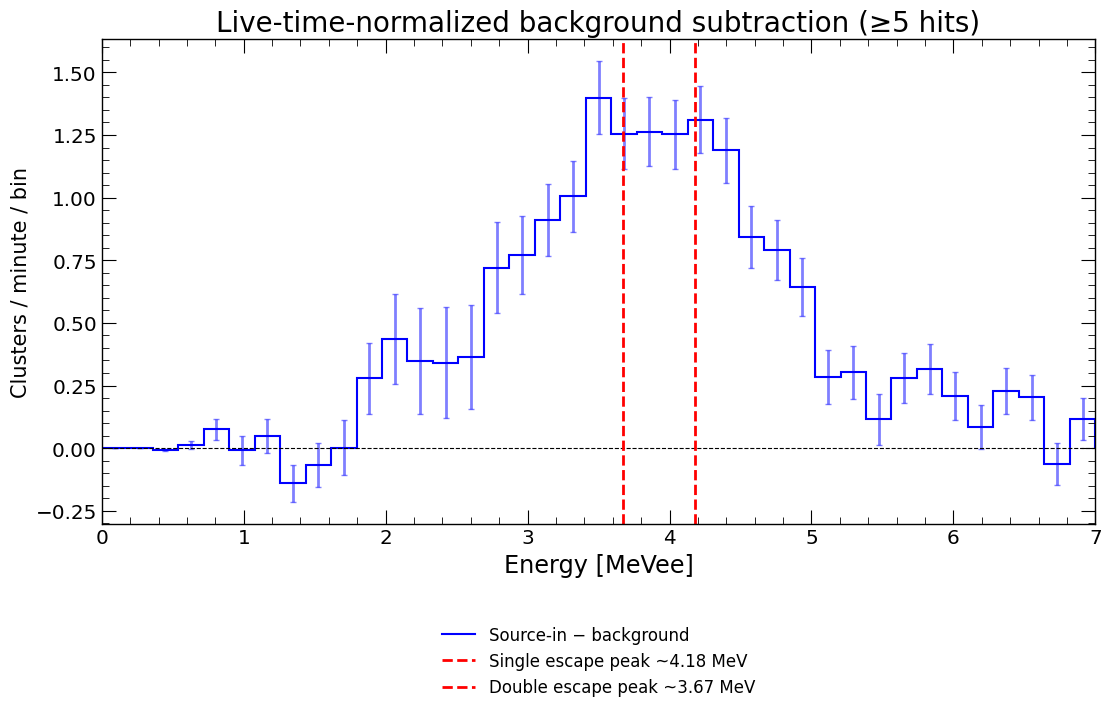

In [19]:
# Data-only version: keep the same live-time subtraction, uncertainties, and peak lines.
_ = plot_data_mc_comparison(
    subtracted_rate, subtracted_rate_uncertainty, mc_counts, energy_bins,
    selection_label, peaks=peaks, show_mc=False,
)


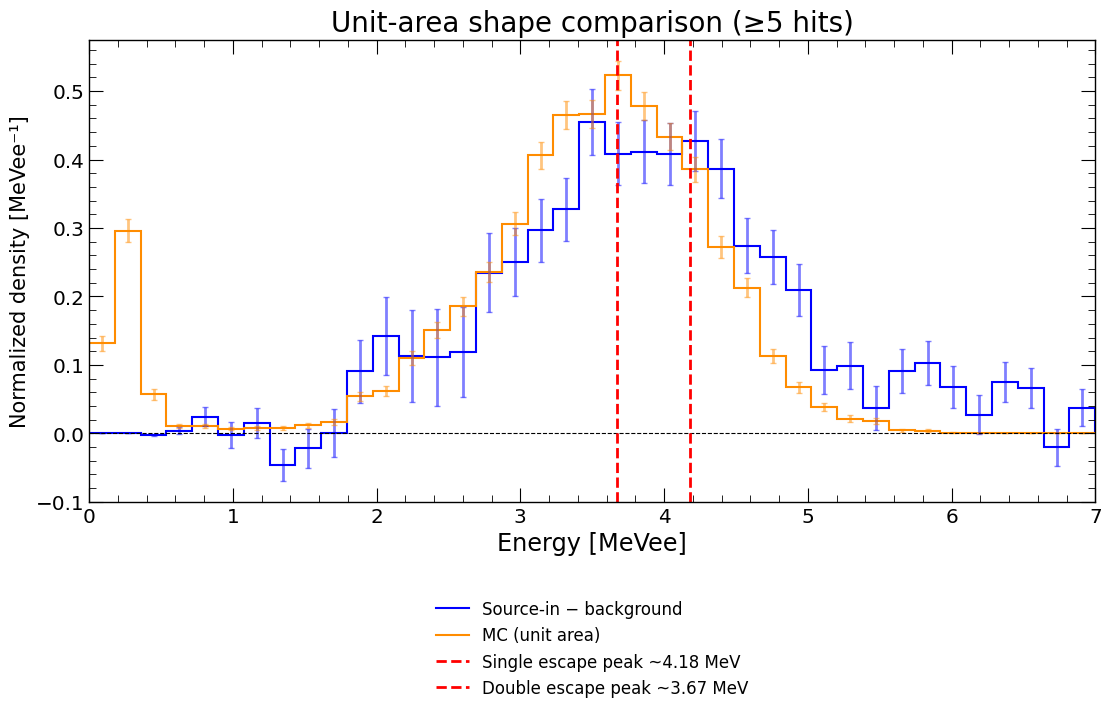

In [20]:
# Normalize data and MC separately over the full common histogram range.
_ = plot_data_mc_comparison(
    subtracted_rate, subtracted_rate_uncertainty, mc_counts, energy_bins,
    selection_label, peaks=peaks, normalize=True,
)


In [21]:
background_scale = source_exposure_min / background_exposure_min
print(f"Source exposure:     {source_exposure_min:.3f} minutes")
print(f"Background exposure: {background_exposure_min:.3f} minutes")
print(f"Equivalent count-space background scale: {background_scale:.6f}")

Source exposure:     264.470 minutes
Background exposure: 1087.385 minutes
Equivalent count-space background scale: 0.243217


In [22]:
# Trying to search for inelastic scatters...

max_hits = 2
cluster_summary_cut = cluster_summary.loc[cluster_summary["n_hits"] >= max_hits]
cluster_summary_bkg_cut = cluster_summary_bkg.loc[cluster_summary_bkg["n_hits"] >= max_hits]
cluster_summary_MC_cut = cluster_summary_MC.loc[cluster_summary_MC["n_hits"] >= max_hits]


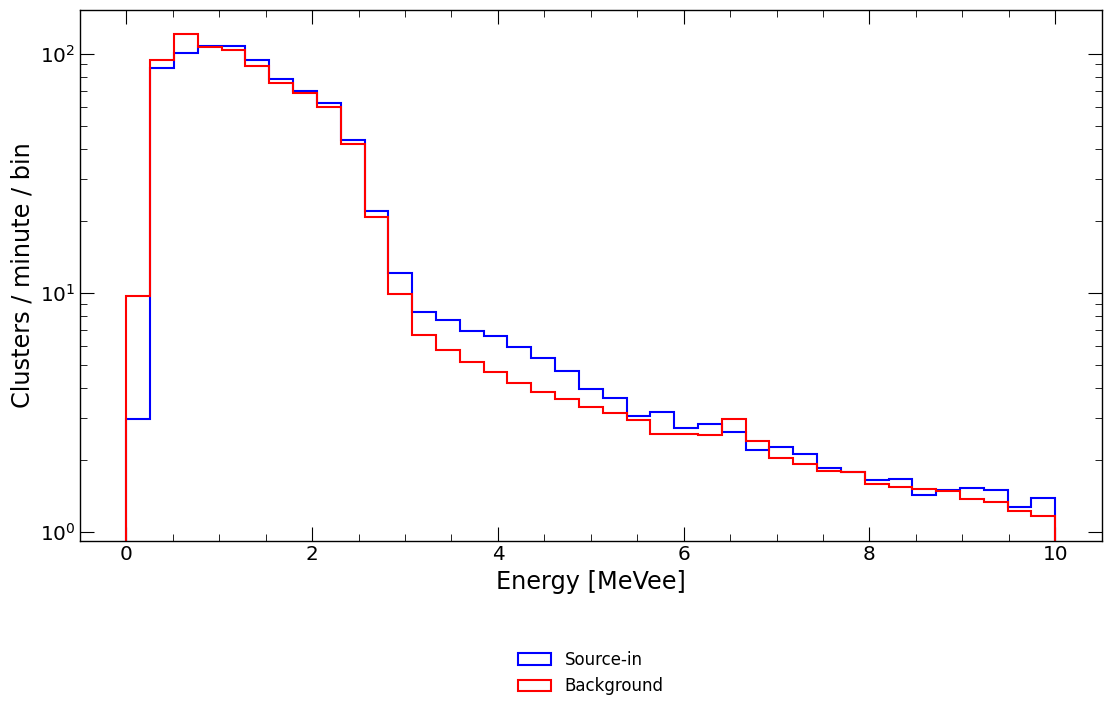

In [23]:
plt.figure(figsize=(11, 7), layout="constrained")
energy_bins = np.linspace(0, 10, 40)
plt.hist(
    cluster_summary_cut["total_E_ee"], bins=energy_bins, histtype="step", color="blue",
    weights=np.full(len(cluster_summary_cut), 1.0 / source_exposure_min), label="Source-in",
)
plt.hist(
    cluster_summary_bkg_cut["total_E_ee"], bins=energy_bins, histtype="step", color="red",
    weights=np.full(len(cluster_summary_bkg_cut), 1.0 / background_exposure_min), label="Background",
)
plt.yscale('log')
plt.xlabel('Energy [MeVee]')
plt.ylabel('Clusters / minute / bin')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.show()

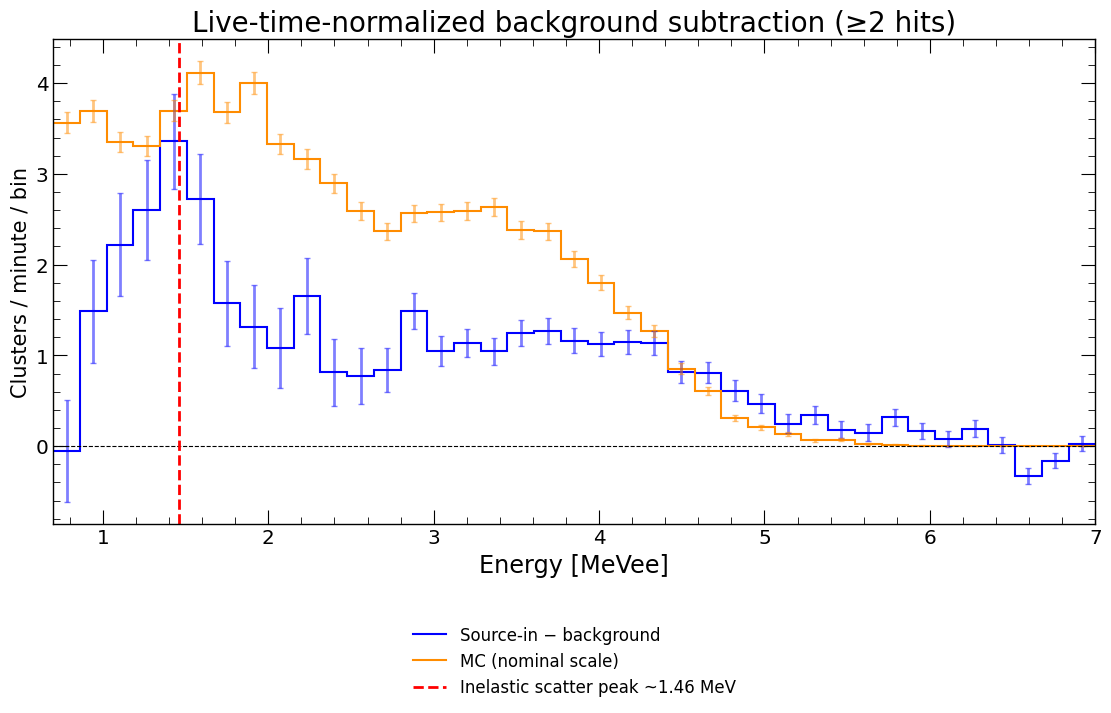

In [34]:
# Subtract exposure-normalized rates using common energy bins for data and MC.
energy_bins = np.linspace(0.7,7., 40)
source_counts, _ = np.histogram(cluster_summary_cut["total_E_ee"], bins=energy_bins)
background_counts, _ = np.histogram(cluster_summary_bkg_cut["total_E_ee"], bins=energy_bins)
mc_counts, _ = np.histogram(cluster_summary_MC_cut["total_E_ee"], bins=energy_bins)

source_rate = source_counts / source_exposure_min
background_rate = background_counts / background_exposure_min
subtracted_rate = source_rate - background_rate

# Independent Poisson counting uncertainty, propagated after exposure normalization.
subtracted_rate_uncertainty = np.sqrt(
    source_counts / source_exposure_min**2
    + background_counts / background_exposure_min**2
)
selection_label = f"≥{max_hits} hits"
peaks = [(1.46, "Inelastic scatter peak ~1.46 MeV")]
_ = plot_data_mc_comparison(
    subtracted_rate, subtracted_rate_uncertainty, mc_counts, energy_bins,
    selection_label, peaks=peaks,
)


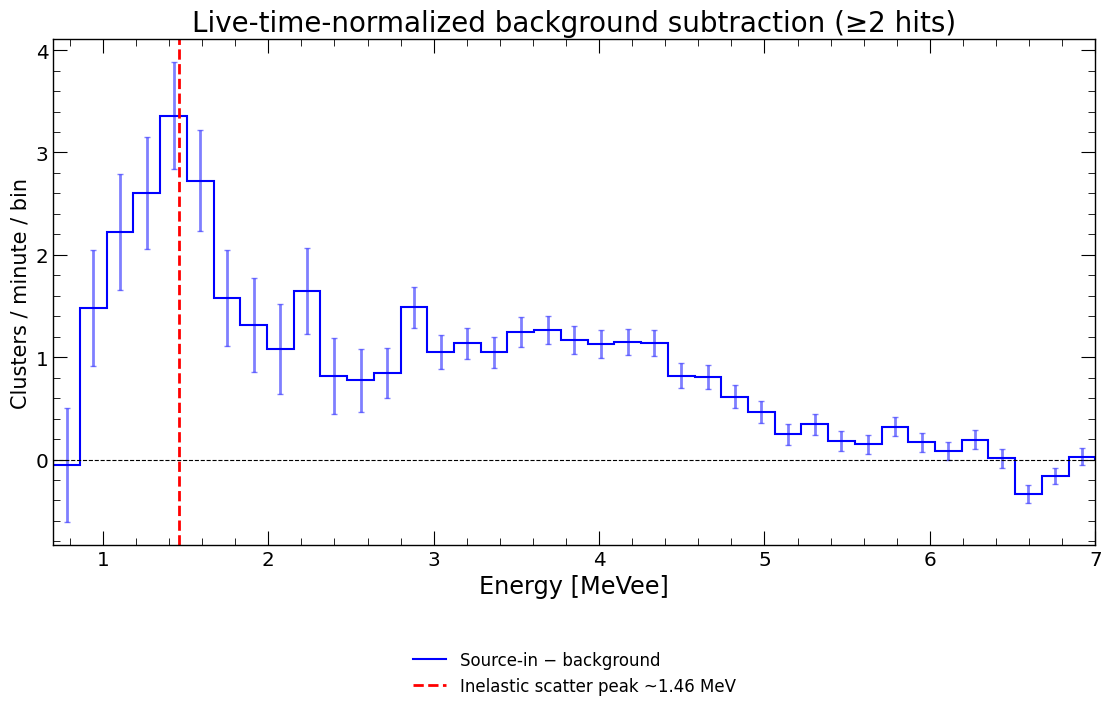

In [35]:
# Data-only version: keep the same live-time subtraction, uncertainties, and peak lines.
_ = plot_data_mc_comparison(
    subtracted_rate, subtracted_rate_uncertainty, mc_counts, energy_bins,
    selection_label, peaks=peaks, show_mc=False,
)


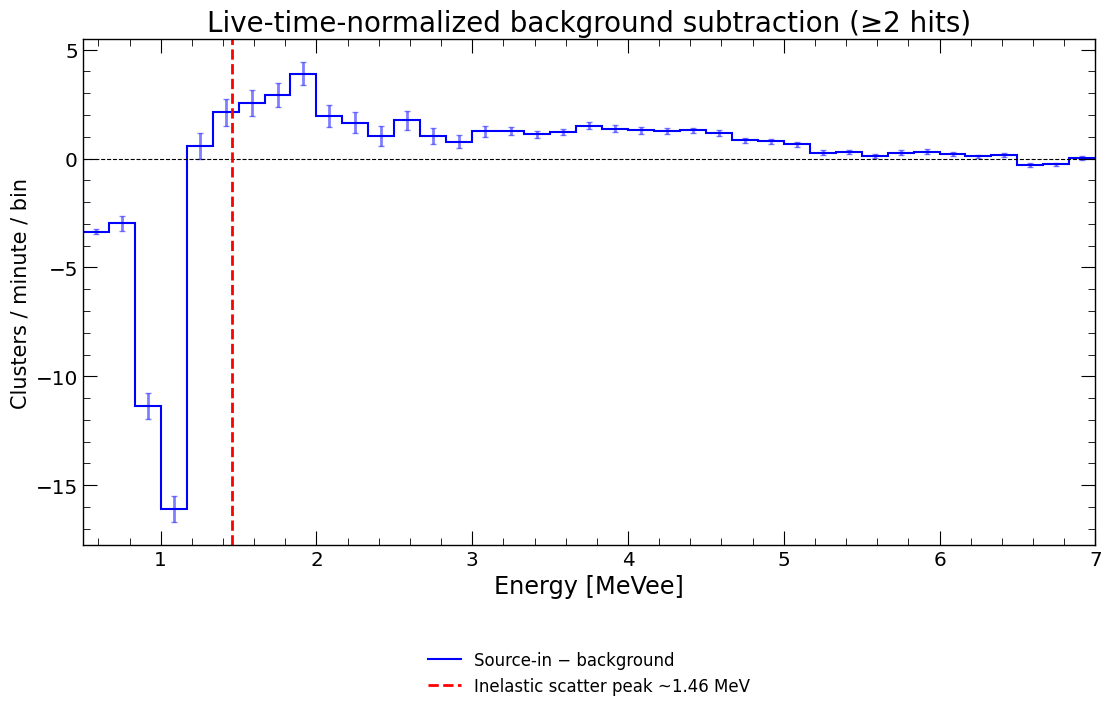

In [30]:
# Data-only version: keep the same live-time subtraction, uncertainties, and peak lines.
energy_bins = np.linspace(0.5, 7., 40)
_ = plot_data_mc_comparison(
    subtracted_rate, subtracted_rate_uncertainty, mc_counts, energy_bins,
    selection_label, peaks=peaks, show_mc=False,
)

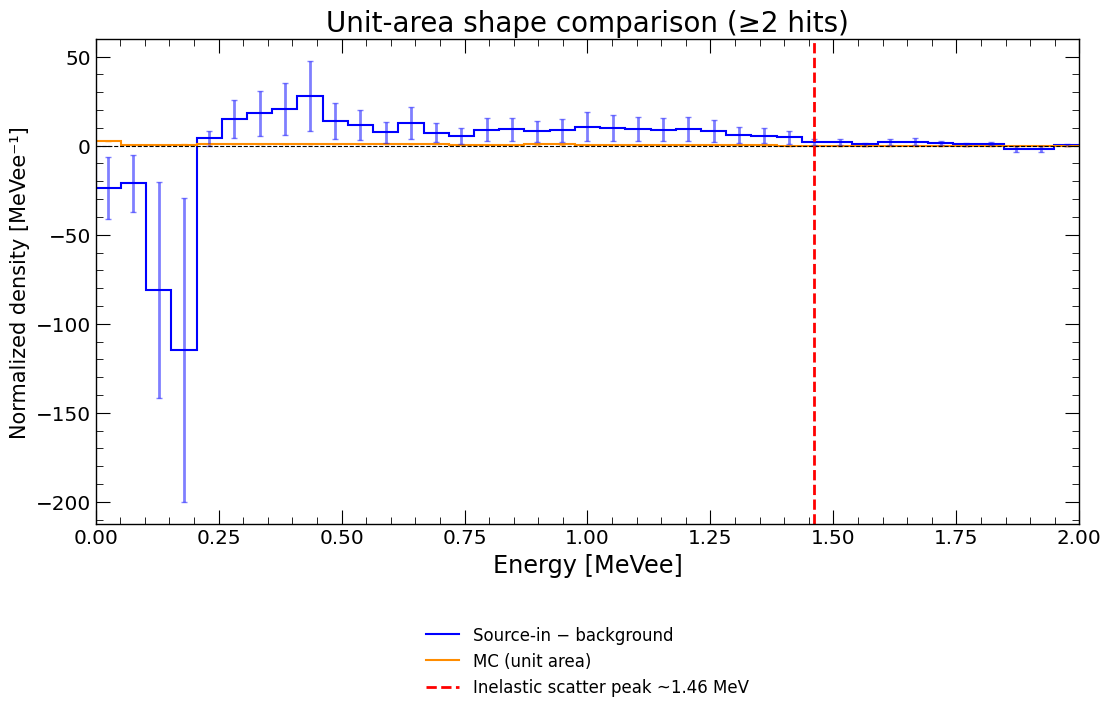

In [27]:
# Normalize data and MC separately over the full common histogram range.
_ = plot_data_mc_comparison(
    subtracted_rate, subtracted_rate_uncertainty, mc_counts, energy_bins,
    selection_label, peaks=peaks, normalize=True,
)
